In [1]:
# defining default font size:
import matplotlib.pyplot as plt
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)



In [2]:
# creating images/decision_trees folder and define save_fig() function for saving figures  :
from pathlib import Path

IMAGES_PATH = Path() / "images" / "decision_trees"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
    

# Dimensionality Reduction 

## PCA 

NOTE:
- identifies axis accounting for largest amount of variance
- singular value factorization technique is used for finding the principal component (PC)
- python's svd() function can be used for obtaining principal component 

In [3]:
import numpy as np
from scipy.spatial.transform import Rotation
m = 60
X = np.zeros((m,3)) #initialize 3d dataset
np.random.seed(42)
angles= (np.random.rand(m) **3 + 0.5) *2 * np.pi # uneven distribution
X[:,0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5 # oval 
X += 0.28 * np.random.randn(m,3) # add more noise
X = Rotation.from_rotvec([np.pi / 29, -np.pi /20, np.pi / 4]). apply (X)
X += [0.2, 0, 0.2]#shift a bit

X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)
c1 = Vt[0]
c2 = Vt[1]

### Projecting to d Dimensions

X(d proj) = X * W(d)

In [5]:
W2 = Vt[:2].T
X2D = X_centered @ W2

for performing SVD in sklearn we use PCA class which automatically takes care of centering of data 

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X2d = pca.fit_transform(X)

#### Explained Variance Ratio

- explained_variance_ratio_ variable is used
- ratio indicates the proportion of dataset's variance that lies along each principal component


In [7]:
pca.explained_variance_ratio_

array([0.7578477 , 0.15186921])

##### Choosing right number of dimensions

In [8]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1 # d equals 154
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)
pca.n_components_ 

np.int64(154)

154 is the actual number of components determined during training

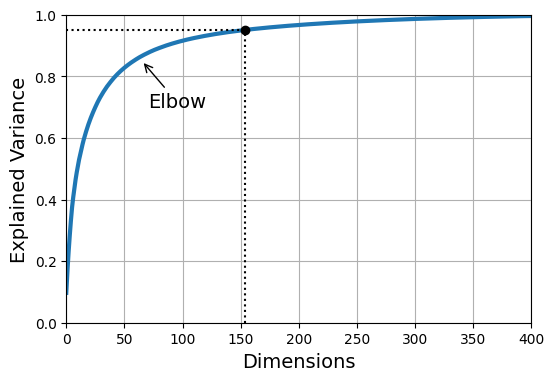

In [9]:
# or we can plot the figure
plt.figure(figsize=(6,4))
plt.plot(cumsum, linewidth=3)
plt.xlabel('Dimensions')
plt.ylabel('Explained Variance')
plt.grid()
plt.axis([0, 400, 0, 1])
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.annotate("Elbow",  xy=(65, 0.85), xytext=(70, 0.7),
             arrowprops = dict(arrowstyle="->"))
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

clf = make_pipeline(PCA(random_state=42), RandomForestClassifier(random_state=42))
param_distrib = {
    "pca__n_components": np.arange(10, 80),
    "randomforestclassifier__n_estimators":np.arange(50, 500)
}
rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3,
                                random_state=42)
rnd_search.fit(X_train[:1000], y_train[:1000])
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': np.int64(475), 'pca__n_components': np.int64(57)}


#### PCA For Compression

In [11]:
pca = PCA(0.95)
X_reduced = pca.fit_transform(X_reduced)

In [12]:
X_recovered = pca.inverse_transform(X_reduced)

##### Randomized PCA

In [13]:
rnd_pca = PCA(n_components = 154, svd_solver = "randomized", random_state=42)
X_reduced = rnd_pca.fit_transform(X_train)

In [14]:
X_reduced

array([[ 123.93258864,  312.67426198,   24.51405174, ...,   62.00213296,
          -8.8147422 ,  -66.93993166],
       [1011.71837586,  294.85703831, -596.33956108, ...,   24.52514836,
          26.58534428,   16.99077095],
       [ -51.84960804, -392.17315289,  188.50974941, ...,    8.99144972,
          -2.99473092,   56.93622984],
       ...,
       [-178.0534496 , -160.0782111 ,  257.61308227, ...,  -35.30439525,
          -2.75142691,   23.97581712],
       [ 130.60607212,    5.59193632, -513.85867376, ...,   15.84132904,
         -18.38612585,   39.40742042],
       [-173.43595246,   24.71880228, -556.01889398, ...,  -29.62816702,
         -52.61652274,   27.99524134]], shape=(60000, 154))

In [15]:
#just an experiment what if we use the svd_solver = "full" for using the full SVD method??
r_p = PCA(n_components= 154, svd_solver = "full", random_state=42)
X_R = r_p.fit_transform(X_train)

In [16]:
X_R

array([[ 123.93258866,  312.67426202,   24.51405176, ...,   55.01899792,
          20.08327427,   39.58995229],
       [1011.71837587,  294.85703827, -596.33956104, ...,    7.24129874,
          12.45780869,  -12.7432306 ],
       [ -51.84960805, -392.17315286,  188.50974943, ...,  -54.19582221,
         -48.47979747,  -73.27826256],
       ...,
       [-178.0534496 , -160.07821109,  257.61308227, ...,   55.54485537,
         -87.99883556,   -5.78979735],
       [ 130.60607208,    5.59193642, -513.85867395, ...,   23.30835402,
          -5.06237836,  -65.26525587],
       [-173.43595244,   24.71880226, -556.01889393, ...,   52.4956069 ,
         -12.63192292,  -45.74001227]], shape=(60000, 154))

NOTE: 
- Difference between "randomized" and "full" is that in randomized it quickly finds an approx of the first d principal components whereas in full the sklearn uses full SVD for a slightly more precise result 

In [17]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components = 154)
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(X_train)

In [18]:
from sklearn.decomposition import IncrementalPCA

n_batches = 200
inc_pca = IncrementalPCA(n_components= 154)
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)

X_Re = inc_pca.transform(X_train)

In [19]:
X_reduced

array([[ 123.93240015,  312.67412765,   24.51396855, ...,   55.02414967,
         -18.82319306,   57.12605157],
       [1011.71883902,  294.85791533, -596.3396284 , ...,   40.79115354,
         -28.52753525,  -32.93944347],
       [ -51.84977972, -392.17395257,  188.50798593, ...,   18.5109603 ,
         -75.96611653,   -7.67736302],
       ...,
       [-178.0534095 , -160.07838721,  257.61233558, ...,  -57.3811145 ,
           6.70673288,  -54.26797595],
       [ 130.60654125,    5.59174593, -513.85834969, ...,  -22.43044205,
          12.51568244,  -36.3004746 ],
       [-173.43566358,   24.71937319, -556.01892138, ...,  -48.33215133,
          19.2936437 ,  -30.58306681]], shape=(60000, 154))

In [20]:
X_Re

array([[ 123.93233749,  312.67393587,   24.51354801, ...,  -64.94684725,
          27.58240756,  -59.75058343],
       [1011.71894428,  294.85808111, -596.33978928, ...,  -49.94682751,
         -28.93950499,   27.78817685],
       [ -51.84953051, -392.1734084 ,  188.50857303, ...,  -60.07760989,
         -24.47741784,  -32.18595098],
       ...,
       [-178.0535643 , -160.0785596 ,  257.6123422 , ...,   21.78169595,
         -65.33149285,   85.94301743],
       [ 130.60679928,    5.592015  , -513.85858291, ...,  -41.69245278,
         -44.57368589,   49.24904703],
       [-173.43555454,   24.71955272, -556.01906239, ...,   32.30537514,
         -24.82613807,   52.86951444]], shape=(60000, 154))

In [21]:
#another way to do this is by  using memmap class from numpy 
filename = "my_mnist.mmap"
X_mmap = np.memmap(filename, dtype='float32', mode='write', shape=X_train.shape)
X_mmap[:] = X_train # could be a loop instead, saving the data chunk by chunk
X_mmap.flush()   #fulsh() is used to ensure that any data still in the cache gets saved to disk 

In [22]:
X_mmap

memmap([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784), dtype=float32)

In [23]:
X_mmap = np.memmap(filename, dtype='float32', mode='readonly').reshape(-1, 784)
batch_size = X_mmap.shape[0] // n_batches 
inc_pca = IncrementalPCA(n_components = 154, batch_size=batch_size)
inc_pca.fit(X_mmap)

,"n_components n_components: int, default=NoneNumber of components to keep. If ``n_components`` is ``None``,then ``n_components`` is set to ``min(n_samples, n_features)``.",154
,"whiten whiten: bool, default=FalseWhen True (False by default) the ``components_`` vectors are dividedby ``n_samples`` times ``components_`` to ensure uncorrelated outputswith unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimesimprove the predictive accuracy of the downstream estimators bymaking data respect some hard-wired assumptions.",False
,"copy copy: bool, default=TrueIf False, X will be overwritten. ``copy=False`` can be used tosave memory but is unsafe for general use.",True
,"batch_size batch_size: int, default=NoneThe number of samples to use for each batch. Only used when calling``fit``. If ``batch_size`` is ``None``, then ``batch_size``is inferred from the data and set to ``5 * n_features``, to provide abalance between approximation accuracy and memory consumption.",300


## Random Projection

In [24]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim
m, ε = 5_000, 0.1 # for writing epsilon just use Alt+ 238(on numpad) 
d = johnson_lindenstrauss_min_dim(m, eps=ε)
d 

np.int64(7300)

In [25]:
n = 20_000
np.random.seed(42)
P = np.random.randn(d, n ) / np.sqrt(d)  # std dev = square root of variance

X = np.random.rand(m,n) # generate a fake dataset
X_reduced = X @ P.T

In [26]:
X_reduced

array([[ 1.03106027, -0.58071396,  0.17748255, ..., -0.50042922,
        -0.89346154, -0.43554483],
       [ 1.17693697, -0.89642533,  0.62791001, ..., -0.76768814,
        -0.31961216, -1.48720284],
       [ 0.70282539, -0.85146873,  0.42702968, ..., -0.96208856,
        -0.9439247 , -0.63170412],
       ...,
       [-0.63096425, -1.49938586, -0.06893654, ..., -1.23091392,
        -0.86821949, -1.6160644 ],
       [ 0.18524848, -0.94593742, -0.03711207, ..., -0.78606154,
        -1.74770332, -1.19454389],
       [ 0.65137076, -0.96300846,  0.49840298, ..., -1.19600257,
        -0.35263461, -1.70285705]], shape=(5000, 7300))

In [27]:
from sklearn.random_projection import GaussianRandomProjection

gaussian_rnd_proj = GaussianRandomProjection(eps=ε, random_state=42)
X_reduced = gaussian_rnd_proj.fit_transform(X) 

In [ ]:
components_pinv = np.linalg.pinv(gaussian_rnd_proj.components_)
X_recovered = X_reduced @ components_pinv.T

## LLE

Locally Linear Embedding (LLE) is a nonlinear dimensionality reduction (NLDR) technique 
- doesn't rely on projections , unlike PCA and random projection

In [39]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_unrolled = lle.fit(X_swiss)

In [44]:

X_train = mnist.data[:60000]
y_train = mnist.target[:60000]

X_test = mnist.data[60000:]
y_test = mnist.target[60000:]

In [45]:
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
%time rnd_clf.fit(X_train, y_train)